# 03 - Identifying the Lateral Action Channel

The contrastive probe compares left and right instructions on one translation
component of the first predicted action. Everything downstream therefore rests on which component
carries image-lateral movement, and with which sign. This notebook identifies
both empirically and characterises how reliably the identified channel tracks
a named object, before any constructed scene exists.

Unaltered validation-role frames are used, disjoint from the bases the
constructed scenes are built on. Each trial is `pick up the {noun}` against the
original frame and against a horizontally mirrored copy, scored against the
object's side of the gripper. The verb is fixed so scenes differ only in the
named object. Rates are split by that side, a pooled toward-object rate cannot
separate tracking from an image-left prior. A horizontal flip reverses image x
and nothing else, so the lateral channel is the one that reverses.

Scenes labelled `duplicate_target='yes'` are excluded, because two instances make
the term-free instruction ambiguous. Every remaining candidate is re-detected,
exactly one instance of the named noun and a detected gripper are required.

The identification proceeds in stages. Sections 12 to 14 score the assumed
reading (component 0 as image x, positive sign) and show it fails. Sections 15
and 16 scan all three components. Sections 17 and 18 bring in the demonstration
ground truth and both sign conventions, which fix the channel at component 1
with the inverted sign. Section 19 states the verdict and the reliability of
the identified channel.

The outcome is recorded in `data.AXIS_INDEX` and
`compose_scenes.IMAGE_X_TO_LATERAL_SIGN`, which the constructed-scene notebooks
read rather than re-deriving.

**Prerequisite:** Notebook 02 has harvested frames and run the duplicate
auto-pass under `openvla_cache/v2/bridge/`.

## 1. Dependencies

OpenVLA-7B loads only against the pinned dependency set, which is installed here
rather than inherited from another session. The
pins, the interpreter assertion, and the verification match Notebook 05, because
this notebook also loads the 7B weights in a fresh runtime.


In [12]:
import subprocess
import sys
from importlib.metadata import version

REQUIRED_PYTHON = (3, 12)
COLAB_RUNTIME_VERSION = '2026.07'

PINS = [
    'transformers==4.40.1',
    'tokenizers==0.19.1',
    'timm==0.9.10',
    'huggingface_hub==0.23.4',
    'accelerate==0.30.1',
    'bitsandbytes>=0.45.0',
    'protobuf>=6.31.1,<7',
]
EXPECTED = {
    'transformers': '4.40.1',
    'tokenizers': '0.19.1',
    'timm': '0.9.10',
    'huggingface_hub': '0.23.4',
    'accelerate': '0.30.1',
}

assert sys.version_info[:2] == REQUIRED_PYTHON, (
    f'Python {sys.version_info.major}.{sys.version_info.minor} is active, but the pinned '
    f'dependencies require Python {REQUIRED_PYTHON[0]}.{REQUIRED_PYTHON[1]}. Set Runtime > '
    f'Change runtime type > Runtime version to {COLAB_RUNTIME_VERSION}, then reconnect and '
    f'run this notebook from the top.'
)

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', '--only-binary=:all:', *PINS],
    check=True,
)

installed = {name: version(name) for name in EXPECTED}
for name, found in installed.items():
    print(f'{name:16s} {found}')

mismatched = {n: v for n, v in installed.items() if v != EXPECTED[n]}
assert not mismatched, (
    'Installed versions differ from the pin: '
    + ', '.join(f'{n} {v} (expected {EXPECTED[n]})' for n, v in mismatched.items())
    + '. Re-run this cell and check the install reported no error.'
)

imported = {n: getattr(sys.modules[n], '__version__', '') for n in EXPECTED
            if n in sys.modules}
stale = {n: v for n, v in imported.items() if v and v != EXPECTED[n]}
assert not stale, (
    'These packages were imported before the install and the session is still '
    'running the earlier code: '
    + ', '.join(f'{n} {v} (expected {EXPECTED[n]})' for n, v in stale.items())
    + '. Restart the session (Runtime > Restart session) and run from the top.'
)
print(f'\nPython {sys.version.split()[0]}, pinned dependency set active')


transformers     4.40.1
tokenizers       0.19.1
timm             0.9.10
huggingface_hub  0.23.4
accelerate       0.30.1

Python 3.12.13, pinned dependency set active


## 2. Mount Drive

`HF_HOME` is pointed at the Drive cache so OpenVLA's 7B weights are not
downloaded again. OWLv2 is loaded onto the runtime disk instead.


In [13]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.environ['HF_HOME'] = '/content/drive/MyDrive/openvla_cache/hf'
CACHE_DIR = '/content/drive/MyDrive/openvla_cache/v2/bridge'
TRACKING_SET = os.path.join(CACHE_DIR, 'object_tracking_set.csv')
TRACKING_REVIEW = os.path.join(CACHE_DIR, 'object_tracking_review.csv')
TRACKING_CSV = '/content/drive/MyDrive/openvla_cache/v2/object_tracking.csv'
assert os.path.isfile(os.path.join(CACHE_DIR, 'manifest.csv')), (
    f'No manifest at {CACHE_DIR}, run the harvest in Notebook 02 first.'
)
print('cache    ->', CACHE_DIR)
print('geometry ->', TRACKING_SET)
print('log      ->', TRACKING_CSV)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cache    -> /content/drive/MyDrive/openvla_cache/v2/bridge
geometry -> /content/drive/MyDrive/openvla_cache/v2/bridge/object_tracking_set.csv
log      -> /content/drive/MyDrive/openvla_cache/v2/object_tracking.csv


## 3. Import the code


In [14]:
import sys, os, importlib, subprocess

REPO_URL = 'https://github.com/LewisTL/ECS8056.git'
BRANCH = 'master'
REPO_DIR = '/content/ECS8056'

def sync_repo():
    """Clone or hard-refresh the repository so it matches origin/BRANCH."""
    token = os.environ.get('GITHUB_TOKEN', '')
    url = REPO_URL.replace('https://', f'https://{token}@') if token else REPO_URL
    if os.path.isdir(os.path.join(REPO_DIR, '.git')):
        subprocess.run(['git', '-C', REPO_DIR, 'remote', 'set-url', 'origin', url],
                       check=True)
        subprocess.run(['git', '-C', REPO_DIR, 'fetch', '--quiet', '--depth', '1',
                        'origin', BRANCH], check=True)
        subprocess.run(['git', '-C', REPO_DIR, 'reset', '--hard', '--quiet',
                        f'origin/{BRANCH}'], check=True)
    else:
        subprocess.run(['git', 'clone', '--quiet', '--depth', '1', '--branch',
                        BRANCH, url, REPO_DIR], check=True)
    return subprocess.run(['git', '-C', REPO_DIR, 'rev-parse', '--short', 'HEAD'],
                          capture_output=True, text=True).stdout.strip()


commit = sync_repo()
module_dir = REPO_DIR
if module_dir not in sys.path:
    sys.path.insert(0, module_dir)
for _m in ('action_bins', 'prediction_log', 'model', 'data', 'controls',
           'compose_scenes', 'detect_duplicates', 'analysis'):
    sys.modules.pop(_m, None)
importlib.invalidate_caches()

from model import (load_openvla, predict_action_dist, describe_action_space,
                   verify_readout, run_metadata, append_prediction_log)
from prediction_log import ensure_readable, tracking_log_fields
from data import load_manifest
from controls import apply_image_transform, IMAGE_MIRROR, IMAGE_ORIGINAL, ROLE_NEUTRAL
from compose_scenes import (IMAGE_X_TO_LATERAL_SIGN, LATERAL_ACTION_INDEX,
                            GRIPPER_SOURCE_DETECTED, locate_gripper)
from detect_duplicates import detect_instances, release_detectors
from analysis import (
    OBJECT_SIDE_LEFT, OBJECT_SIDE_RIGHT, TRACKING_CONDITION_MIRROR,
    TRACKING_CONDITION_ORIGINAL, TRACKING_INSTRUCTION, TRACKING_SET_FIELDS,
    apply_tracking_instruction, attach_tracking_ground_truth, mirrored_x,
    object_side_image, object_tracking_by_axis, object_tracking_by_sign,
    object_tracking_candidates, object_tracking_gate, object_tracking_report,
    proportion_lower_bound, stale_tracking_prompt_count,
    tracking_gt_predictions, tracking_instruction,
)
import pandas as pd
print(f'imported project modules from {module_dir} @ {commit}')


imported project modules from /content/ECS8056 @ 050bcc0


## 4. Candidate pool

Validation-role frames whose wording yields a clean spatial-term strip and a
nameable object. The prompt sent at inference is `pick up the {noun}`, not the
stripped Bridge sentence, so leftover verbs do not vary across the gate. Scenes
already labelled as holding two instances are dropped here. Instance count for
the rest is decided by detection in the next section, not by the harvest label.


In [15]:
pool = object_tracking_candidates(load_manifest(CACHE_DIR))
print(f"{pool['n']} candidates after the wording filter")
print('skipped:', dict(pool['skipped']))
candidates = pool['rows']
assert candidates, (
    'no validation-role frames passed the wording filter. Run the harvest and '
    'the duplicate auto-pass in Notebook 02 first.'
)


1013 candidates after the wording filter
skipped: {'split': 16000, 'duplicate': 20, 'pair': 0, 'strip': 2, 'noun': 0}


## 5. Detect geometry

OWLv2 locates the named object, the gripper helpers locate the start position.
A scene enters the tracking set only when exactly one instance is found and the
gripper is detected rather than fallen back to the image centre. Already-written
rows are skipped, so an interrupted pass resumes.


In [16]:
import csv
from collections import Counter
from PIL import Image

existing = {}
if os.path.isfile(TRACKING_SET):
    with open(TRACKING_SET, newline='') as f:
        for row in csv.DictReader(f):
            existing[row['scene_id']] = row
    print(f'resuming geometry: {len(existing)} scenes already recorded')

funnel = Counter()
new_rows = []
for item in candidates:
    scene_id = f"b{int(item['episode_index']):06d}"
    if scene_id in existing:
        continue
    rel = item.get('image_path') or ''
    path = os.path.join(CACHE_DIR, rel)
    if not rel or not os.path.isfile(path):
        funnel['no_image'] += 1
        continue
    image = Image.open(path).convert('RGB')
    found = detect_instances(image, item['noun'])
    funnel[f'n_instances_{len(found)}'] += 1
    if len(found) != 1:
        continue
    inst = found[0]
    gx, gy, gsrc, gscore = locate_gripper(image)
    if gsrc != GRIPPER_SOURCE_DETECTED:
        funnel['gripper_fallback'] += 1
        continue
    side = object_side_image(inst.center_x, gx)
    if side == 0:
        funnel['on_gripper_column'] += 1
        continue
    new_rows.append({
        'scene_id': scene_id,
        'episode_index': int(item['episode_index']),
        'instruction': item['instruction'],
        'instr_neutral': item['instr_neutral'],
        'spatial_term': item['spatial_term'],
        'noun': item['noun'],
        'image_path': rel,
        'image_width': int(image.width),
        'image_height': int(image.height),
        'x_object': float(inst.center_x),
        'y_object': float(inst.center_y),
        'object_score': float(inst.score),
        'x_gripper': float(gx),
        'y_gripper': float(gy),
        'gripper_source': gsrc,
        'gripper_score': float(gscore),
        'object_side_image': int(side),
    })

if new_rows or not os.path.isfile(TRACKING_SET):
    write_header = not os.path.isfile(TRACKING_SET)
    with open(TRACKING_SET, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=list(TRACKING_SET_FIELDS))
        if write_header:
            writer.writeheader()
        for row in new_rows:
            writer.writerow(row)

geometry_rows = []
with open(TRACKING_SET, newline='') as f:
    geometry_rows = list(csv.DictReader(f))
apply_tracking_instruction(geometry_rows)
if geometry_rows:
    with open(TRACKING_SET, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=list(TRACKING_SET_FIELDS))
        writer.writeheader()
        for row in geometry_rows:
            writer.writerow({k: row.get(k, '') for k in TRACKING_SET_FIELDS})
print(f'detected this pass: {len(new_rows)}')
print(f'tracking set: {len(geometry_rows)} scenes at {TRACKING_SET}')
print('funnel:', dict(funnel))
sides = Counter(int(r['object_side_image']) for r in geometry_rows)
print(f"object-left: {sides.get(-1, 0)}  object-right: {sides.get(1, 0)}")
assert geometry_rows, (
    'no single-object scenes with a detected gripper. The first-action gate '
    'cannot run on this pool.'
)


resuming geometry: 197 scenes already recorded
[detect_duplicates] loading google/owlv2-base-patch16-ensemble into /tmp/hf_local


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:99: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/620M [00:00<?, ?B/s]

detected this pass: 0
tracking set: 197 scenes at /content/drive/MyDrive/openvla_cache/v2/bridge/object_tracking_set.csv
funnel: {'n_instances_2': 213, 'n_instances_0': 312, 'n_instances_1': 106, 'gripper_fallback': 97, 'n_instances_3': 101, 'n_instances_4': 42, 'on_gripper_column': 9, 'n_instances_9': 2, 'n_instances_5': 11, 'n_instances_6': 10, 'n_instances_10': 2, 'n_instances_7': 7, 'n_instances_8': 9, 'n_instances_12': 1}
object-left: 94  object-right: 103


## 6. Stimulus screen

Approve a scene only when the frame shows exactly one clear instance of
the named noun. The judgement is blind to any prediction. Set
`REQUIRE_SCREEN = True` to admit only approved scenes into the inference below,
leave it False to use the detector's single-instance set as-is.

The page is a container whose `children` are replaced rather than an `Output`
widget written into, because the Colab widget manager does not instantiate widget
views nested inside an `Output`.


In [17]:
import ipywidgets as widgets
from IPython.display import display
from PIL import Image, ImageDraw

REQUIRE_SCREEN = True

review = {}
if os.path.isfile(TRACKING_REVIEW):
    with open(TRACKING_REVIEW, newline='') as f:
        for row in csv.DictReader(f):
            review[row['scene_id']] = row.get('approved', '')

queue = [r for r in geometry_rows if r['scene_id'] not in review]
print(f'reviewed: {len(review)}  still to screen: {len(queue)}')
print('REQUIRE_SCREEN =', REQUIRE_SCREEN)

state = {'idx': 0, 'done': 0}
status_label = widgets.HTML()
meta_label = widgets.HTML()
img_panel = widgets.HBox([])
btn_yes = widgets.Button(description='Approve', button_style='success')
btn_no = widgets.Button(description='Reject', button_style='danger')
btn_skip = widgets.Button(description='Skip')


def _write_review(scene_id, approved):
    write_header = not os.path.isfile(TRACKING_REVIEW)
    with open(TRACKING_REVIEW, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['scene_id', 'approved'])
        if write_header:
            writer.writeheader()
        writer.writerow({'scene_id': scene_id, 'approved': approved})
    review[scene_id] = approved


def _annotated(row):
    path = os.path.join(CACHE_DIR, row['image_path'])
    image = Image.open(path).convert('RGB')
    draw = ImageDraw.Draw(image)
    xo, yo = float(row['x_object']), float(row['y_object'])
    gx, gy = float(row['x_gripper']), float(row['y_gripper'])
    r = 12
    draw.ellipse((xo - r, yo - r, xo + r, yo + r), outline=(0, 200, 80), width=3)
    draw.ellipse((gx - r, gy - r, gx + r, gy + r), outline=(220, 40, 40), width=3)
    return image


def _show_current():
    if state['idx'] >= len(queue):
        status_label.value = (
            f"<b>Screen complete.</b> Labeled {state['done']} scene(s) this run."
        )
        meta_label.value = ''
        img_panel.children = ()
        return
    row = queue[state['idx']]
    status_label.value = (
        f"Scene {state['idx'] + 1} / {len(queue)} "
        f"(labeled this run: {state['done']})"
    )
    meta_label.value = (
        f"<b>{row['scene_id']}</b> noun=<code>{row['noun']}</code> "
        f"side={'left' if int(row['object_side_image']) < 0 else 'right'}<br>"
        f"{row['instr_neutral']}"
    )
    image = _annotated(row)
    from io import BytesIO
    buf = BytesIO()
    image.save(buf, format='PNG')
    img_panel.children = (
        widgets.Image(value=buf.getvalue(), format='png', width=480),
    )


def _save(approved):
    if state['idx'] >= len(queue):
        return
    _write_review(queue[state['idx']]['scene_id'], approved)
    state['done'] += 1
    state['idx'] += 1
    _show_current()


btn_yes.on_click(lambda _: _save('yes'))
btn_no.on_click(lambda _: _save('no'))
btn_skip.on_click(lambda _: (state.update(idx=state['idx'] + 1), _show_current()))

display(widgets.VBox([status_label, meta_label, img_panel,
                      widgets.HBox([btn_yes, btn_no, btn_skip])]))
_show_current()


reviewed: 197  still to screen: 0
REQUIRE_SCREEN = True


## 7. Freeze the inference pool

Apply the screen if it was required, then free the detector so OpenVLA can use
the GPU.


In [18]:
if os.path.isfile(TRACKING_REVIEW):
    with open(TRACKING_REVIEW, newline='') as f:
        review = {r['scene_id']: r.get('approved', '') for r in csv.DictReader(f)}
else:
    review = {}

REQUIRE_SCREEN = globals().get('REQUIRE_SCREEN', False)

if REQUIRE_SCREEN:
    tracking_scenes = [r for r in geometry_rows if review.get(r['scene_id']) == 'yes']
    print(f'screen required: {len(tracking_scenes)} approved of {len(geometry_rows)}')
    assert tracking_scenes, (
        'REQUIRE_SCREEN is True but no scene is approved. Run the screen, or set '
        'REQUIRE_SCREEN = False to use the detector set.'
    )
else:
    tracking_scenes = list(geometry_rows)
    n_approved = sum(1 for r in tracking_scenes if review.get(r['scene_id']) == 'yes')
    print(f'using detector set: {len(tracking_scenes)} scenes '
          f'({n_approved} of them also approved)')

apply_tracking_instruction(tracking_scenes)
print('prompt template:', TRACKING_INSTRUCTION)
print('examples:', sorted({r['instr_neutral'] for r in tracking_scenes})[:8])

release_detectors()
print('detector released')


screen required: 98 approved of 197
prompt template: pick up the {noun}
examples: ['pick up the banana', 'pick up the block', 'pick up the bowl', 'pick up the broccoli', 'pick up the brush', 'pick up the bunny', 'pick up the carrot', 'pick up the cheese']
detector released


## 8. Load OpenVLA-7B


In [19]:
processor, vla, compute_dtype = load_openvla(quantize_4bit=True, precision='bf16')
meta = run_metadata(compute_dtype)
print(meta)


[load_openvla] GPU: NVIDIA A100-SXM4-40GB (sm_80, 39.5 GB) | precision=bf16 | attn=eager | 4bit=True


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

[load_openvla] Loaded. GPU memory allocated: 4.09 GB
{'gpu_name': 'NVIDIA A100-SXM4-40GB', 'gpu_capability': 'sm_80', 'dtype': 'bfloat16', 'seed': 42, 'torch': '2.11.0+cu128', 'transformers': '4.40.1', 'bitsandbytes': '0.50.2'}


## 9. Action space and readout constants


In [20]:
space = describe_action_space(vla)
BIN_WIDTH = float(space['bin_width'][0])
print(f'lateral (dx) bin width: {BIN_WIDTH:.6f}')
print(f'sign convention IMAGE_X_TO_LATERAL_SIGN = {IMAGE_X_TO_LATERAL_SIGN:+d}')


lateral (dx) bin width: 0.000225
sign convention IMAGE_X_TO_LATERAL_SIGN = -1


## 10. Readout correctness gate

The continuous value is used only after recomputing the argmax from the captured
scores reproduces `predict_action` on stimuli from this pool.


In [21]:
from PIL import Image

GATE_MINIMUM = 20
n_gate = min(50, len(tracking_scenes))
assert n_gate >= GATE_MINIMUM, (
    f'the tracking set holds {len(tracking_scenes)} scenes, at least '
    f'{GATE_MINIMUM} are needed to verify the readout.'
)
samples = []
for row in tracking_scenes[:n_gate]:
    image = Image.open(os.path.join(CACHE_DIR, row['image_path'])).convert('RGB')
    samples.append((image, row['instr_neutral']))
summary = verify_readout(processor, vla, samples, compute_dtype)
print(f"continuous readout verified on {summary['checked']} tracking prompts")


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:957: UserWarning: inner dimension (4304) is not aligned for fast kernel with blocksize=64, falling back to slower implementation.
  warn(


[verify_readout] 50/50 exact | max deviation 0.000e+00 | min action-token mass 0.0000
continuous readout verified on 50 tracking prompts


## 11. Predict original and mirrored object-seeking actions

Two predictions per scene, resume-safe on `(scene_id, condition)`. The prompt
is `pick up the {noun}` on both the original and the mirrored image. A log
written under leftover Bridge wording is refused rather than resumed.


In [22]:
import csv
from PIL import Image

if not os.path.exists(TRACKING_CSV) or os.path.getsize(TRACKING_CSV) == 0:
    with open(TRACKING_CSV, 'w', newline='') as f:
        csv.DictWriter(f, fieldnames=tracking_log_fields()).writeheader()
ensure_readable(TRACKING_CSV)

done = set()
if os.path.exists(TRACKING_CSV) and os.path.getsize(TRACKING_CSV) > 0:
    with open(TRACKING_CSV, newline='') as f:
        logged = list(csv.DictReader(f))
    stale = stale_tracking_prompt_count(logged)
    assert stale == 0, (
        f'{stale} logged predictions used a different prompt than '
        "'pick up the {noun}'."
    )
    for r in logged:
        done.add((r['scene_id'], r.get('condition')))
    print(f'resuming: {len(done)} predictions already logged')

work = []
for row in tracking_scenes:
    work.append((row, TRACKING_CONDITION_ORIGINAL, IMAGE_ORIGINAL))
    work.append((row, TRACKING_CONDITION_MIRROR, IMAGE_MIRROR))
print(f'{len(work)} predictions over {len(tracking_scenes)} scenes')


def run_tracking(items, label='', report_every=50):
    ran = 0
    for i, (row, condition, transform) in enumerate(items):
        key = (row['scene_id'], condition)
        if key in done:
            continue
        image = Image.open(os.path.join(CACHE_DIR, row['image_path'])).convert('RGB')
        image = apply_image_transform(transform, image)
        readout = predict_action_dist(processor, vla, image, row['instr_neutral'],
                                      compute_dtype)
        extra = {
            'scene_id': row['scene_id'],
            'episode_index': row['episode_index'],
            'role': ROLE_NEUTRAL,
            'condition': condition,
            'image_transform': transform,
            'noun': row['noun'],
            'spatial_term': row['spatial_term'],
            'sample_idx': 0,
        }
        append_prediction_log(
            TRACKING_CSV, readout.action, row['instr_neutral'], meta,
            readout=readout, **extra)
        done.add(key)
        ran += 1
        if report_every and ran % report_every == 0:
            print(f'{label}{ran} predictions run ({i + 1}/{len(items)} seen)')
    return ran


/content/drive/MyDrive/openvla_cache/v2/object_tracking.csv
  55 columns, 196 rows, consistent
resuming: 196 predictions already logged
196 predictions over 98 scenes


## 12. Pilot

Forty scenes, split across object-left and object-right, before the full pool.
The scoring here reads the assumed layout, component 0 as image x with the
positive sign. Each cell is judged on the one-sided lower confidence bound of
its rate against chance, not on a point threshold, so a verdict reflects the
evidence rather than the cell size. A fail on this reading is not a dead end.
The sections below scan every component and both signs to find where the
image-x signal actually lives.


In [23]:
import pandas as pd

PILOT_SCENES = 40
ASSUMED_SIGN = 1
FLOOR = 0.5          # each cell must be demonstrably better than a coin flip
CONFIDENCE = 0.95    # one-sided Wilson lower bound
MIN_N_PER_SIDE = 8   # pilot slice

left = [r for r in tracking_scenes if int(r['object_side_image']) < 0]
right = [r for r in tracking_scenes if int(r['object_side_image']) > 0]
n_each = max(PILOT_SCENES // 2, 1)
pilot_scenes = left[::max(len(left) // n_each, 1)][:n_each]
pilot_scenes += right[::max(len(right) // n_each, 1)][:n_each]
pilot_ids = {r['scene_id'] for r in pilot_scenes}
pilot_work = [w for w in work if w[0]['scene_id'] in pilot_ids]
print(f'pilot: {len(pilot_work)} predictions over {len(pilot_ids)} scenes '
      f'(left={sum(int(r["object_side_image"]) < 0 for r in pilot_scenes)}, '
      f'right={sum(int(r["object_side_image"]) > 0 for r in pilot_scenes)})')

ran = run_tracking(pilot_work, label='pilot: ', report_every=20)
print(f'pilot new predictions: {ran}')

preds = pd.read_csv(TRACKING_CSV)
preds = preds[preds['scene_id'].isin(pilot_ids) & preds['c0'].notna()]
geom = pd.DataFrame(pilot_scenes)
report = object_tracking_report(
    preds, geom, min_magnitude=BIN_WIDTH, lateral_sign=ASSUMED_SIGN)
gate = object_tracking_gate(
    report, floor=FLOOR, confidence=CONFIDENCE, min_n_per_side=MIN_N_PER_SIDE)

def _print_report(report, gate):
    print(f"n={report['n']}  toward original={report['toward_original']:.1%}  "
          f"toward mirrored={report['toward_mirror']:.1%}  "
          f"flip={report['flip_rate']:.1%}")
    for name, entry in report['by_object_side'].items():
        print(f"  {name:6} n={entry['n']:4}  toward orig={entry['toward_original']:.1%}  "
              f"toward mir={entry['toward_mirror']:.1%}  flip={entry['flip_rate']:.1%}")
    print('verdict:', 'pass' if gate['pass'] else 'fail')
    for reason in gate['reasons']:
        print(' ', reason)

_print_report(report, gate)
if not gate['pass']:
    print('\nassumed reading (component 0, positive sign) does not track on '
          'this slice. The scans below locate the image-x signal.')


pilot: 80 predictions over 40 scenes (left=20, right=20)
pilot new predictions: 0
n=40  toward original=63.9%  toward mirrored=67.6%  flip=36.4%
  left   n=  20  toward orig=94.7%  toward mir=47.1%  flip=50.0%
  right  n=  20  toward orig=29.4%  toward mir=85.0%  flip=23.5%
verdict: fail
  left mirrored toward-object 47.1% (n=17), lower bound 29.0% not above 50%
  left flip rate 50.0% (n=16), lower bound 31.0% not above 50%
  right original toward-object 29.4% (n=17), lower bound 15.1% not above 50%
  right flip rate 23.5% (n=17), lower bound 11.0% not above 50%
  overall flip rate 36.4% (n=33), lower bound 24.1% not above 50%

assumed reading (component 0, positive sign) does not track on this slice. The scans below locate the image-x signal.


## 13. Full pool

The remaining scenes. Pilot predictions are skipped by the resume key.


In [24]:
ran = run_tracking(work, label='sweep: ', report_every=50)
print(f'sweep new predictions: {ran} -> {TRACKING_CSV}')


sweep new predictions: 0 -> /content/drive/MyDrive/openvla_cache/v2/object_tracking.csv


## 14. The assumed reading on the full pool

Toward-object must hold on both sides of the gripper, on both the original and
the mirrored frame, and the action must reverse under the mirror, each cell on
its lower confidence bound. An image-left prior fails this, it is high on the
left, low on the right, and does not flip.

Component 0 under the positive sign fails here. Read on its own, that fail is
ambiguous between a dead visual channel, the signal sitting on another
component, and an inverted sign. The remaining sections separate those
accounts. The verdict on the identified channel is section 19.


In [25]:
FULL_MIN_N_PER_SIDE = 10

preds = pd.read_csv(TRACKING_CSV)
preds = preds[preds['c0'].notna()]
geom = pd.DataFrame(tracking_scenes)
report = object_tracking_report(
    preds, geom, min_magnitude=BIN_WIDTH, lateral_sign=ASSUMED_SIGN)
gate = object_tracking_gate(
    report, floor=FLOOR, confidence=CONFIDENCE,
    min_n_per_side=FULL_MIN_N_PER_SIDE)
_print_report(report, gate)
print(f'\nmin_magnitude = {BIN_WIDTH:.7f} (one component-0 bin)')
print(f'assumed reading: component 0, sign {ASSUMED_SIGN:+d}')
if gate['pass']:
    print('\ncomponent 0 under the positive sign tracks a unique named object '
          'and reverses under a mirror.')
else:
    print('\ncomponent 0 under the positive sign is not the image-x channel '
          'on these frames. Sections 15 to 18 locate the channel.')


n=98  toward original=47.2%  toward mirrored=73.4%  flip=25.9%
  left   n=  40  toward orig=81.6%  toward mir=43.2%  flip=37.1%
  right  n=  58  toward orig=21.6%  toward mir=93.0%  flip=18.0%
verdict: fail
  left mirrored toward-object 43.2% (n=37), lower bound 30.8% not above 50%
  left flip rate 37.1% (n=35), lower bound 25.1% not above 50%
  right original toward-object 21.6% (n=51), lower bound 13.7% not above 50%
  right flip rate 18.0% (n=50), lower bound 10.8% not above 50%
  overall flip rate 25.9% (n=85), lower bound 18.9% not above 50%

min_magnitude = 0.0002246 (one component-0 bin)
assumed reading: component 0, sign +1

component 0 under the positive sign is not the image-x channel on these frames. Sections 15 to 18 locate the channel.


## 15. Translation components

The check above scored component 0. A horizontal flip reverses image x, so the
component that is lateral must reverse. If a component keeps one sign on the
original and mirrored frames, scoring it as lateral produces a high
toward-object rate when the object sits left of the gripper and a low rate
when it sits right, which is the pattern of a constant approach as well as of
an image-left prior.

This cell reads the existing tracking log. It scores `dx`, `dy`, and `dz` the
same way, each against its own bin width, still under the assumed positive
sign. The true image-x channel flips and tracks the object on both sides. A
component that stays one sign on both frames is not that channel. A component
that flips but scores low on toward-object under this sign is the signature of
an inverted convention, which section 18 resolves.


In [26]:
def _fmt_rate(value):
    return f"{value:.1%}" if value == value else "undefined"


def _fmt_mean(value):
    return f"{value:+.6f}" if value == value else "undefined"


preds = pd.read_csv(TRACKING_CSV)
preds = preds[preds['c0'].notna()]
geom = pd.DataFrame(tracking_scenes)
bin_widths = space['bin_width']
scan = object_tracking_by_axis(
    preds, geom, lateral_sign=ASSUMED_SIGN, bin_widths=bin_widths)

print('Each translation component scored as if it were image-x, '
      f'under the assumed sign {ASSUMED_SIGN:+d}.')
print('A live lateral channel flips and tracks the object on both sides.')
print()
for axis, report in scan.items():
    mag = report['min_magnitude']
    print(f"=== {report['name']} (index {axis}, bin width {mag:.7f}) ===")
    print(f"  n={report['n']}  flip={_fmt_rate(report['flip_rate'])}  "
          f"identical={_fmt_rate(report['identical_rate'])}")
    print(f"  negative orig={_fmt_rate(report['negative_rate_original'])}  "
          f"negative mir={_fmt_rate(report['negative_rate_mirror'])}")
    print(f"  mean orig={_fmt_mean(report['mean_original'])}  "
          f"mean mir={_fmt_mean(report['mean_mirror'])}")
    print(f"  toward orig={_fmt_rate(report['toward_original'])}  "
          f"toward mir={_fmt_rate(report['toward_mirror'])}")
    for name, entry in report['by_object_side'].items():
        print(f"    {name:6} n={entry['n']:4}  "
              f"toward orig={_fmt_rate(entry['toward_original'])}  "
              f"toward mir={_fmt_rate(entry['toward_mirror'])}  "
              f"flip={_fmt_rate(entry['flip_rate'])}")
    axis_gate = object_tracking_gate(
        report, floor=FLOOR, confidence=CONFIDENCE,
        min_n_per_side=FULL_MIN_N_PER_SIDE)
    print('  same check:', 'pass' if axis_gate['pass'] else 'fail')
    if not axis_gate['pass']:
        for reason in axis_gate['reasons']:
            print('   ', reason)
    print()


Each translation component scored as if it were image-x, under the assumed sign +1.
A live lateral channel flips and tracks the object on both sides.

=== dx (index 0, bin width 0.0002246) ===
  n=98  flip=25.9%  identical=0.0%
  negative orig=79.8%  negative mir=78.7%
  mean orig=-0.002109  mean mir=-0.001925
  toward orig=47.2%  toward mir=73.4%
    left   n=  40  toward orig=81.6%  toward mir=43.2%  flip=37.1%
    right  n=  58  toward orig=21.6%  toward mir=93.0%  flip=18.0%
  same check: fail
    left mirrored toward-object 43.2% (n=37), lower bound 30.8% not above 50%
    left flip rate 37.1% (n=35), lower bound 25.1% not above 50%
    right original toward-object 21.6% (n=51), lower bound 13.7% not above 50%
    right flip rate 18.0% (n=50), lower bound 10.8% not above 50%
    overall flip rate 25.9% (n=85), lower bound 18.9% not above 50%

=== dy (index 1, bin width 0.0003250) ===
  n=98  flip=65.6%  identical=0.0%
  negative orig=75.3%  negative mir=56.4%
  mean orig=-0.001632

## 16. Axis overlay

The check belongs in the camera image,
where left and right are the object's side of the gripper, so each component
is drawn as if it were image-x and read against the object's position.

Each row is one scene. The left panel is the original frame, the right panel is
the same frame flipped horizontally, with object and gripper drawn at their
mirrored positions. Three horizontal arrows leave the gripper, one per
translation component, using only that component as image-x. Positive is
rightward in the panel. A circle marks the object; a square marks the gripper.

A component that is left/right in the scene points at the object on both
object-left and object-right rows, and reverses on the mirrored panel. A
component that keeps one direction on every panel is not that axis, even if
the rates above look like an image-left prior.

The six scenes are the three largest object-gripper separations on each side,
so the side is readable. Re-run section 3 after pulling so `mirrored_x` is
imported, then run the overlay and the scatter. The model is not loaded again.

The scatter below plots object offset in image x against each component on the
original frame only. A left/right axis is a signed cloud. A constant first
step is a horizontal band.


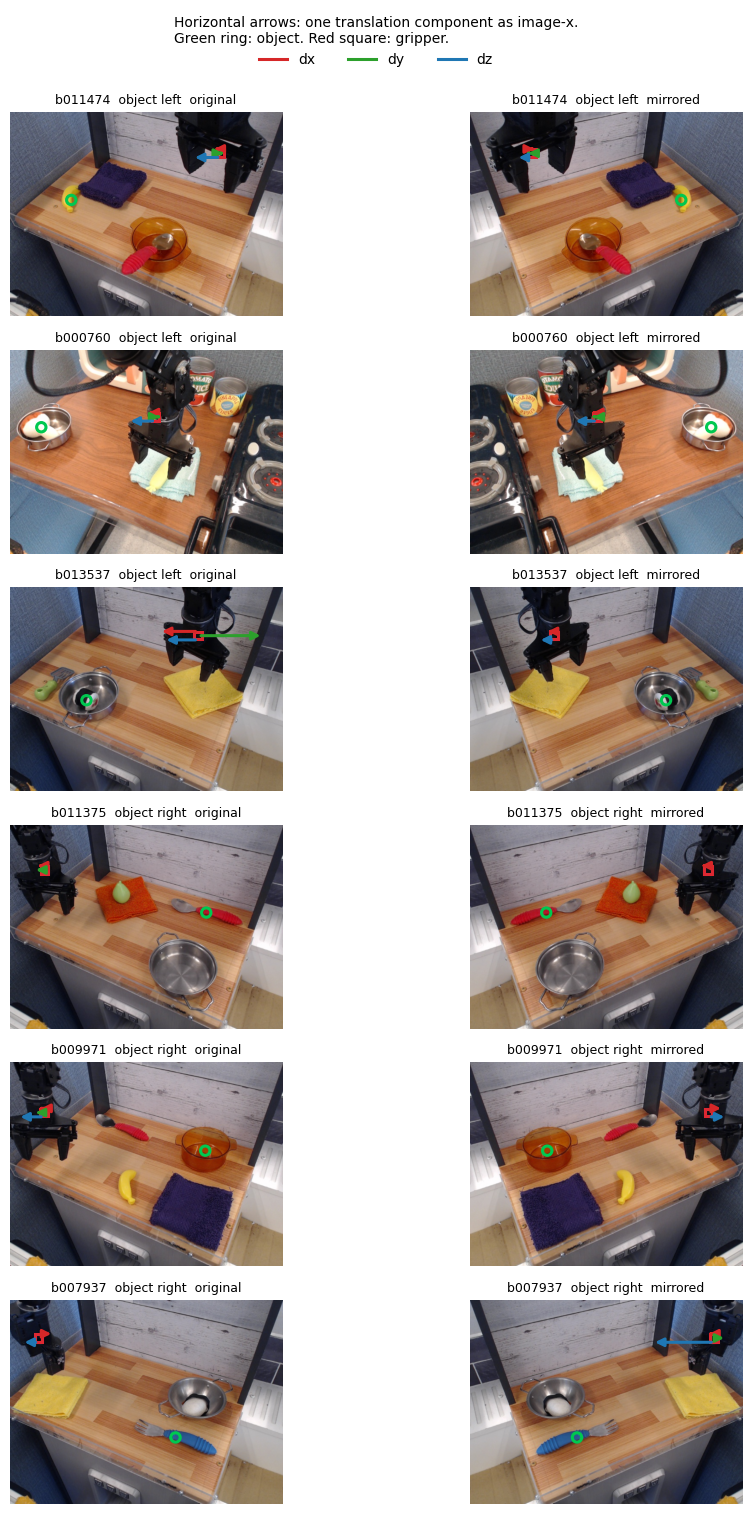

6 scenes  scale = 11003 px per action unit  (longest arrow = 50% of image width)


In [27]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from PIL import Image

N_PER_SIDE = 3
ARROW_SPAN = 0.5  # fraction of image width for the longest component
COMPONENT_COLOURS = (
    (0, 'dx', '#d62728'),
    (1, 'dy', '#2ca02c'),
    (2, 'dz', '#1f77b4'),
)

preds = pd.read_csv(TRACKING_CSV)
preds['scene_id'] = preds['scene_id'].astype(str)
preds = preds[preds['c0'].notna()]
orig_pred = (preds[preds['condition'] == TRACKING_CONDITION_ORIGINAL]
             .drop_duplicates('scene_id').set_index('scene_id'))
mir_pred = (preds[preds['condition'] == TRACKING_CONDITION_MIRROR]
            .drop_duplicates('scene_id').set_index('scene_id'))
logged = set(orig_pred.index.intersection(mir_pred.index))

with open(TRACKING_SET, newline='') as f:
    geom = [r for r in csv.DictReader(f) if str(r['scene_id']) in logged]
left = [r for r in geom if int(r['object_side_image']) < 0]
right = [r for r in geom if int(r['object_side_image']) > 0]
left = sorted(left, key=lambda r: abs(float(r['x_object']) - float(r['x_gripper'])),
              reverse=True)[:N_PER_SIDE]
right = sorted(right, key=lambda r: abs(float(r['x_object']) - float(r['x_gripper'])),
               reverse=True)[:N_PER_SIDE]
overlay_scenes = left + right
assert overlay_scenes, 'no tracking scenes with both original and mirrored predictions'


def _values(scene_id, table):
    row = table.loc[str(scene_id)]
    return [float(row[f'c{i}']) for i in range(3)]


peak = max(
    abs(v)
    for scene in overlay_scenes
    for table in (orig_pred, mir_pred)
    for v in _values(scene['scene_id'], table)
)
peak = max(peak, 1e-6)

n_rows = len(overlay_scenes)
header_in = 0.75
fig_h = 2.4 * n_rows + header_in
fig, axes = plt.subplots(n_rows, 2, figsize=(11, fig_h), squeeze=False)

for row_i, scene in enumerate(overlay_scenes):
    path = os.path.join(CACHE_DIR, scene['image_path'])
    source = Image.open(path).convert('RGB')
    width, height = source.size
    scale = (ARROW_SPAN * width) / peak
    xo, yo = float(scene['x_object']), float(scene['y_object'])
    gx, gy = float(scene['x_gripper']), float(scene['y_gripper'])
    sid = str(scene['scene_id'])
    side = 'left' if int(scene['object_side_image']) < 0 else 'right'
    panels = (
        (source, gx, gy, xo, yo, orig_pred, 'original'),
        (apply_image_transform(IMAGE_MIRROR, source),
         mirrored_x(gx, width), gy,
         mirrored_x(xo, width), yo,
         mir_pred, 'mirrored'),
    )
    for col_i, (image, pgx, pgy, pxo, pyo, table, label) in enumerate(panels):
        ax = axes[row_i, col_i]
        ax.imshow(np.asarray(image))
        ax.add_patch(Circle((pxo, pyo), 11, fill=False, edgecolor='#00c850',
                            linewidth=2.2, zorder=4))
        ax.add_patch(Rectangle((pgx - 9, pgy - 9), 18, 18, fill=False,
                               edgecolor='#dc2832', linewidth=2.2, zorder=4))
        for axis, _name, colour in COMPONENT_COLOURS:
            value = float(table.loc[sid, f'c{axis}'])
            dy = (axis - 1) * 10
            ax.annotate(
                '', xy=(pgx + value * scale, pgy + dy), xytext=(pgx, pgy + dy),
                arrowprops=dict(arrowstyle='-|>', color=colour, lw=2.2,
                                mutation_scale=12),
                zorder=5)
        ax.set_axis_off()
        ax.set_title(f'{sid}  object {side}  {label}', fontsize=9)

handles = [
    plt.Line2D([0], [0], color=colour, lw=2.2, label=name)
    for _, name, colour in COMPONENT_COLOURS
]
top = 1.0 - header_in / fig_h
fig.tight_layout(rect=[0, 0, 1, top])
fig.legend(
    handles=handles,
    loc='lower center',
    bbox_to_anchor=(0.5, top),
    ncol=3,
    frameon=False,
    fontsize=10,
    columnspacing=2.4,
    title=(
        'Horizontal arrows: one translation component as image-x.\n'
        'Green ring: object. Red square: gripper.'
    ),
    title_fontsize=10,
)
plt.show()
print(f'{len(overlay_scenes)} scenes  scale = {scale:.0f} px per action unit  '
      f'(longest arrow = {ARROW_SPAN:.0%} of image width)')


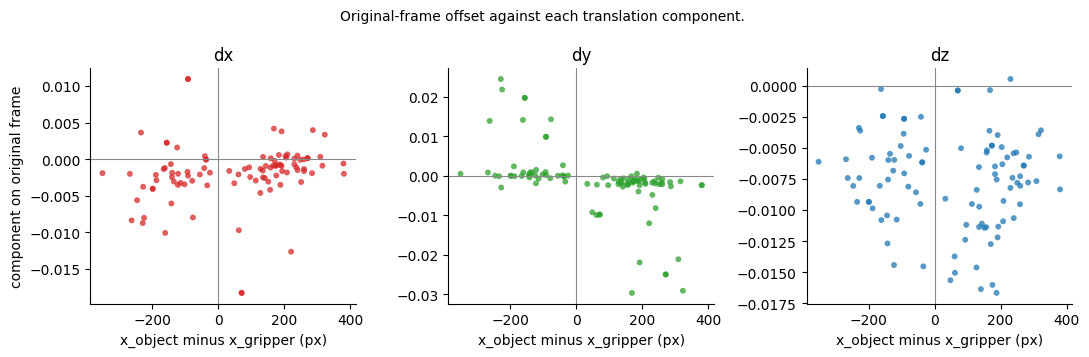

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=False)
offset = np.array([float(r['x_object']) - float(r['x_gripper']) for r in geom])
ids = [str(r['scene_id']) for r in geom]
orig = orig_pred.loc[ids]
for ax, (axis, name, colour) in zip(axes, COMPONENT_COLOURS):
    values = orig[f'c{axis}'].to_numpy(dtype=float)
    ax.axhline(0, color='#888', lw=0.8)
    ax.axvline(0, color='#888', lw=0.8)
    ax.scatter(offset, values, s=18, c=colour, alpha=0.75, edgecolors='none')
    ax.set_xlabel('x_object minus x_gripper (px)')
    ax.set_title(name)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axes[0].set_ylabel('component on original frame')
fig.suptitle(
    'Original-frame offset against each translation component. ',
    fontsize=10)
fig.tight_layout()
plt.show()


## 17. Early-motion ground truth

The checks above score one OpenVLA token. Harvested `gt_dx`, `gt_dy`, and `gt_dz`
are the net demonstration action over the first five non-initial Bridge steps,
after skipping the recorded no-op. That is the early reach in this frame, not a
mirrored trial and not a model bin.

The check is toward-object on both sides of the original frame only. A component
that tracks the object in image x is high on both object-left and object-right.
A constant-sign reach is high on one side and low on the other, the same
signature as the predicted token.

The overlay draws original frames only. The scatter is object offset against
each `gt_*` component. Section 18 then scores `gt_dy` and predicted `c1` under
both image-x signs. Re-run section 3 after pulling, then this section. The
model is not loaded again.


In [29]:
def _fmt_gt_rate(value):
    return f"{value:.1%}" if value == value else "undefined"


def _fmt_gt_mean(value):
    return f"{value:+.6f}" if value == value else "undefined"


GT_FLOOR = globals().get('FLOOR', 0.5)
GT_CONFIDENCE = globals().get('CONFIDENCE', 0.95)
GT_SIGN = globals().get('ASSUMED_SIGN', 1)
GT_MIN_N_PER_SIDE = globals().get('FULL_MIN_N_PER_SIDE', 10)

geom_gt = attach_tracking_ground_truth(tracking_scenes, load_manifest(CACHE_DIR))
gt_preds = tracking_gt_predictions(geom_gt)
n_missing = len(geom_gt) - gt_preds['scene_id'].nunique() if len(gt_preds) else len(geom_gt)
print(f'tracking scenes: {len(geom_gt)}  with ground truth: {len(gt_preds)}  '
      f'missing: {n_missing}')
assert not gt_preds.empty, (
    'no harvested gt_dx, gt_dy, gt_dz on this tracking set. Re-run the harvest '
    'in Notebook 02 so the manifest carries the early-motion vector.'
)

gt_scan = object_tracking_by_axis(
    gt_preds, geom_gt, require_mirror=False, min_magnitude=0.0,
    lateral_sign=GT_SIGN)

print('Early-motion ground truth scored as if each component were image-x, '
      f'under the assumed sign {GT_SIGN:+d}.')
print('No mirrored demonstration, toward-object on the original frame only.')
print()
for axis, report in gt_scan.items():
    print(f"=== gt_{report['name']} (index {axis}) ===")
    print(f"  n={report['n']}  toward orig={_fmt_gt_rate(report['toward_original'])}")
    print(f"  negative={_fmt_gt_rate(report['negative_rate_original'])}  "
          f"mean={_fmt_gt_mean(report['mean_original'])}")
    for name, entry in report['by_object_side'].items():
        print(f"    {name:6} n={entry['n']:4}  "
              f"toward orig={_fmt_gt_rate(entry['toward_original'])}")
    axis_gate = object_tracking_gate(
        report, floor=GT_FLOOR, confidence=GT_CONFIDENCE,
        min_n_per_side=GT_MIN_N_PER_SIDE, require_mirror=False)
    print('  original-only check:', 'pass' if axis_gate['pass'] else 'fail')
    if not axis_gate['pass']:
        for reason in axis_gate['reasons']:
            print('   ', reason)
    print()

print('min_magnitude = 0 (demonstration vector, not an OpenVLA bin)')
print(f'assumed sign for this scan: {GT_SIGN:+d}')


tracking scenes: 98  with ground truth: 98  missing: 0
Early-motion ground truth scored as if each component were image-x, under the assumed sign +1.
No mirrored demonstration, toward-object on the original frame only.

=== gt_dx (index 0) ===
  n=98  toward orig=57.1%
  negative=44.9%  mean=+0.012110
    left   n=  40  toward orig=52.5%
    right  n=  58  toward orig=60.3%
  original-only check: fail
    left original toward-object 52.5% (n=40), lower bound 39.8% not above 50%
    right original toward-object 60.3% (n=58), lower bound 49.5% not above 50%

=== gt_dy (index 1) ===
  n=98  toward orig=3.1%
  negative=58.2%  mean=-0.007973
    left   n=  40  toward orig=2.5%
    right  n=  58  toward orig=3.4%
  original-only check: fail
    left original toward-object 2.5% (n=40), lower bound 0.6% not above 50%
    right original toward-object 3.4% (n=58), lower bound 1.1% not above 50%

=== gt_dz (index 2) ===
  n=98  toward orig=43.9%
  negative=80.6%  mean=-0.024622
    left   n=  40 

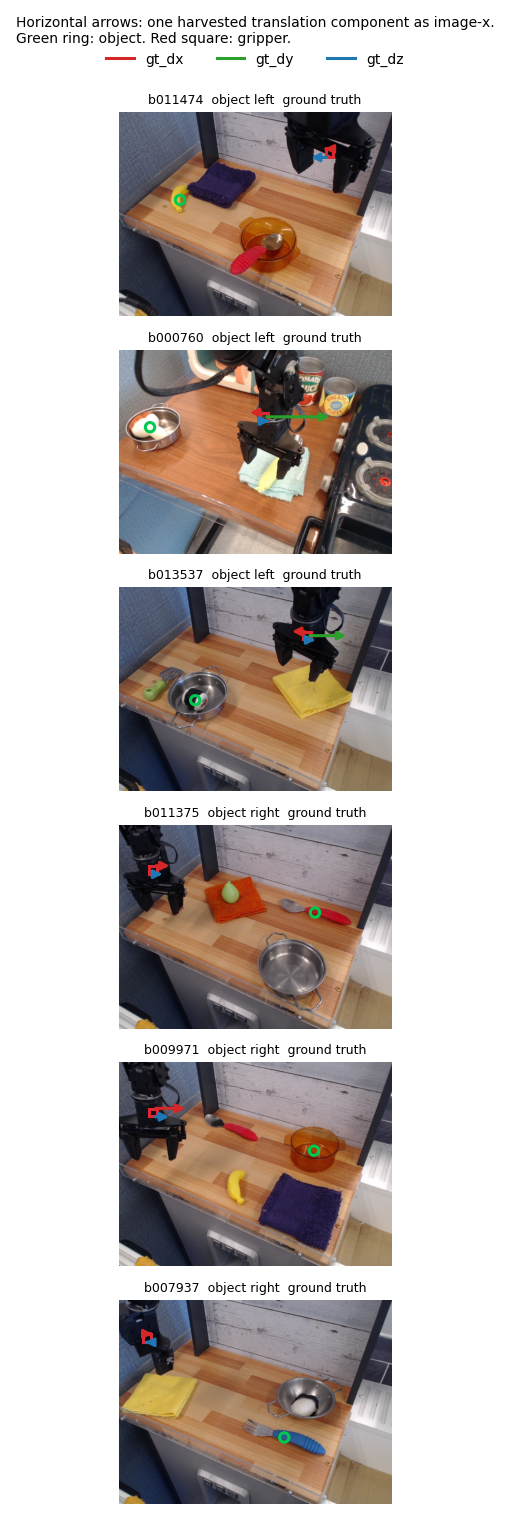

6 scenes  scale = 941 px per action unit


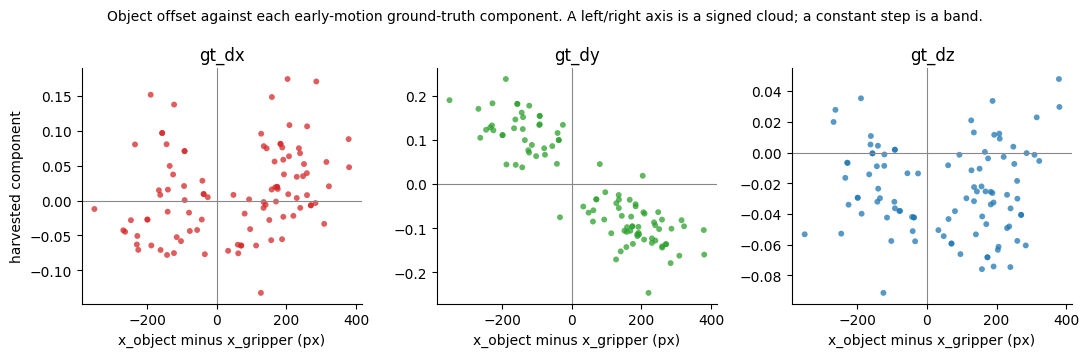

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from PIL import Image

N_PER_SIDE = 3
ARROW_SPAN = 0.28
ARROW_STAGGER = 10
COMPONENT_COLOURS = (
    (0, 'gt_dx', '#d62728'),
    (1, 'gt_dy', '#2ca02c'),
    (2, 'gt_dz', '#1f77b4'),
)

logged = set(gt_preds['scene_id'].astype(str))
geom_rows = geom_gt.to_dict('records')
usable = [r for r in geom_rows if str(r['scene_id']) in logged]
left = [r for r in usable if int(r['object_side_image']) < 0]
right = [r for r in usable if int(r['object_side_image']) > 0]
left = sorted(left, key=lambda r: abs(float(r['x_object']) - float(r['x_gripper'])),
              reverse=True)[:N_PER_SIDE]
right = sorted(right, key=lambda r: abs(float(r['x_object']) - float(r['x_gripper'])),
               reverse=True)[:N_PER_SIDE]
overlay_scenes = left + right
assert overlay_scenes, 'no tracking scenes with harvested ground truth'

gt_table = gt_preds.drop_duplicates('scene_id').copy()
gt_table['scene_id'] = gt_table['scene_id'].astype(str)
gt_table = gt_table.set_index('scene_id')

peak = max(
    abs(float(gt_table.loc[str(s['scene_id']), f'c{i}']))
    for s in overlay_scenes
    for i in range(3)
)
peak = max(peak, 1e-6)

n_rows = len(overlay_scenes)
header_in = 0.85
fig_h = 2.4 * n_rows + header_in
fig, axes = plt.subplots(n_rows, 1, figsize=(6.5, fig_h), squeeze=False)

for row_i, scene in enumerate(overlay_scenes):
    path = os.path.join(CACHE_DIR, scene['image_path'])
    source = Image.open(path).convert('RGB')
    width, _height = source.size
    scale = (ARROW_SPAN * width) / peak
    xo, yo = float(scene['x_object']), float(scene['y_object'])
    gx, gy = float(scene['x_gripper']), float(scene['y_gripper'])
    sid = str(scene['scene_id'])
    side = 'left' if int(scene['object_side_image']) < 0 else 'right'
    ax = axes[row_i, 0]
    ax.imshow(np.asarray(source))
    ax.add_patch(Circle((xo, yo), 11, fill=False, edgecolor='#00c850',
                        linewidth=2.2, zorder=4))
    ax.add_patch(Rectangle((gx - 9, gy - 9), 18, 18, fill=False,
                           edgecolor='#dc2832', linewidth=2.2, zorder=4))
    for axis, _name, colour in COMPONENT_COLOURS:
        value = float(gt_table.loc[sid, f'c{axis}'])
        dy = (axis - 1) * ARROW_STAGGER
        ax.annotate(
            '', xy=(gx + value * scale, gy + dy), xytext=(gx, gy + dy),
            arrowprops=dict(arrowstyle='-|>', color=colour, lw=2.2,
                            mutation_scale=12),
            zorder=5)
    ax.set_axis_off()
    ax.set_title(f'{sid}  object {side}  ground truth', fontsize=9)

handles = [
    plt.Line2D([0], [0], color=colour, lw=2.2, label=name)
    for _, name, colour in COMPONENT_COLOURS
]
top = 1.0 - header_in / fig_h
fig.tight_layout(rect=[0, 0, 1, top])
fig.legend(
    handles=handles,
    loc='lower center',
    bbox_to_anchor=(0.5, top),
    ncol=3,
    frameon=False,
    fontsize=10,
    columnspacing=2.4,
    title=(
        'Horizontal arrows: one harvested translation component as image-x.\n'
        'Green ring: object. Red square: gripper.'
    ),
    title_fontsize=10,
)
plt.show()
print(f'{len(overlay_scenes)} scenes  scale = {scale:.0f} px per action unit')

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=False)
offset = np.array([float(r['x_object']) - float(r['x_gripper']) for r in usable])
ids = [str(r['scene_id']) for r in usable]
orig = gt_table.loc[ids]
for ax, (axis, name, colour) in zip(axes, COMPONENT_COLOURS):
    values = orig[f'c{axis}'].to_numpy(dtype=float)
    ax.axhline(0, color='#888', lw=0.8)
    ax.axvline(0, color='#888', lw=0.8)
    ax.scatter(offset, values, s=18, c=colour, alpha=0.75, edgecolors='none')
    ax.set_xlabel('x_object minus x_gripper (px)')
    ax.set_title(name)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axes[0].set_ylabel('harvested component')
fig.suptitle(
    'Object offset against each early-motion ground-truth component. '
    'A left/right axis is a signed cloud; a constant step is a band.',
    fontsize=10)
fig.tight_layout()
plt.show()


## 18. Sign convention on dy

The ground-truth scatter is a signed cloud on `gt_dy`, inverted relative to
the assumed positive convention. That is why section 17 printed a 3%
toward-object rate on `gt_dy`, object left produced a positive value. This
section scores `gt_dy` and the first predicted `c1` under both signs.

A true image-x channel is high toward-object on both sides under one of the
two conventions. The demonstration ground truth clears the check under the
negative sign, which fixes the convention independently of the model. The
model's `c1` is then read under the same sign. This is the identification the
module constants record: `data.AXIS_INDEX` maps lateral terms to component 1,
and `compose_scenes.IMAGE_X_TO_LATERAL_SIGN` is -1.


In [31]:
def _fmt_sign_rate(value):
    return f'{value:.1%}' if value == value else 'undefined'


def _print_sign_scan(title, scan, *, with_flip):
    print(title)
    for sign in (1, -1):
        if sign not in scan:
            continue
        report = scan[sign]['report']
        gate = scan[sign]['gate']
        line = (f'  sign {sign:+d}  n={report["n"]}  '
                f'toward orig={_fmt_sign_rate(report["toward_original"])}')
        if with_flip:
            line += (f'  toward mir={_fmt_sign_rate(report["toward_mirror"])}  '
                     f'flip={_fmt_sign_rate(report["flip_rate"])}')
        print(line)
        for name, entry in report['by_object_side'].items():
            side = (f'    {name:6} n={entry["n"]:4}  '
                    f'toward orig={_fmt_sign_rate(entry["toward_original"])}')
            if with_flip:
                side += (f'  toward mir={_fmt_sign_rate(entry["toward_mirror"])}  '
                         f'flip={_fmt_sign_rate(entry["flip_rate"])}')
            print(side)
        print('    gate:', 'pass' if gate['pass'] else 'fail')
        if not gate['pass']:
            for reason in gate['reasons']:
                print('     ', reason)
        print()


SIGN_FLOOR = globals().get('FLOOR', 0.5)
SIGN_CONFIDENCE = globals().get('CONFIDENCE', 0.95)
SIGN_MIN_N = globals().get('FULL_MIN_N_PER_SIDE', 10)

geom_sign = attach_tracking_ground_truth(tracking_scenes, load_manifest(CACHE_DIR))
gt_sign_preds = tracking_gt_predictions(geom_sign)
assert not gt_sign_preds.empty, (
    'no harvested gt_dx, gt_dy, gt_dz on this tracking set. Re-run the harvest '
    'in Notebook 02 first.'
)
gt_dy_signs = object_tracking_by_sign(
    gt_sign_preds, geom_sign, axis_index=1, require_mirror=False,
    min_magnitude=0.0, floor=SIGN_FLOOR, confidence=SIGN_CONFIDENCE,
    min_n_per_side=SIGN_MIN_N)
_print_sign_scan(
    'gt_dy (early-motion, original frame only) under both image-x signs.',
    gt_dy_signs, with_flip=False)

model_preds = pd.read_csv(TRACKING_CSV)
model_preds = model_preds[model_preds['c1'].notna()]
bin_widths = space['bin_width']
model_dy_signs = object_tracking_by_sign(
    model_preds, pd.DataFrame(tracking_scenes), axis_index=1,
    min_magnitude=float(bin_widths[1]), floor=SIGN_FLOOR,
    confidence=SIGN_CONFIDENCE, min_n_per_side=SIGN_MIN_N)
_print_sign_scan(
    'model dy (c1, original and mirrored) under the same signs.',
    model_dy_signs, with_flip=True)
print('identified convention, recorded in the modules: component',
      LATERAL_ACTION_INDEX, f'with IMAGE_X_TO_LATERAL_SIGN = '
      f'{IMAGE_X_TO_LATERAL_SIGN:+d}')


gt_dy (early-motion, original frame only) under both image-x signs.
  sign +1  n=98  toward orig=3.1%
    left   n=  40  toward orig=2.5%
    right  n=  58  toward orig=3.4%
    gate: fail
      left original toward-object 2.5% (n=40), lower bound 0.6% not above 50%
      right original toward-object 3.4% (n=58), lower bound 1.1% not above 50%

  sign -1  n=98  toward orig=96.9%
    left   n=  40  toward orig=97.5%
    right  n=  58  toward orig=96.6%
    gate: pass

model dy (c1, original and mirrored) under the same signs.
  sign +1  n=98  toward orig=8.6%  toward mir=25.6%  flip=65.6%
    left   n=  40  toward orig=24.0%  toward mir=16.7%  flip=65.2%
    right  n=  58  toward orig=1.8%  toward mir=33.3%  flip=65.9%
    gate: fail
      left original toward-object 24.0% (n=25), lower bound 13.0% not above 50%
      left mirrored toward-object 16.7% (n=36), lower bound 8.9% not above 50%
      left flip rate 65.2% (n=23), lower bound 48.1% not above 50%
      right original toward-obj

## 19. Verdict

The identification itself is settled by the sections above. The demonstration
ground truth places the image-lateral reach on component 1 with the negative
sign, independently of the model, and the model's `c1` flips under the mirror
and tracks far above the other components under the same convention. That
mapping is recorded in `data.AXIS_INDEX` and
`compose_scenes.IMAGE_X_TO_LATERAL_SIGN`, and the constructed-scene notebooks
read it from there.

Reliability is a separate question and is reported here per cell, as the
one-sided lower confidence bound of each toward-object and flip rate. A cell
whose bound clears one half is demonstrably better than a coin flip on these
frames. Cells that do not clear it bound how much single-scene noise the
contrastive probe must overcome. The probe remains interpretable because it
compares paired instructions on the same frame, but per-scene readings of the
identified channel carry the error rate printed here and are not treated as
exact.

In [32]:
V_FLOOR = globals().get('FLOOR', 0.5)
V_CONFIDENCE = globals().get('CONFIDENCE', 0.95)
V_MIN_N = globals().get('FULL_MIN_N_PER_SIDE', 10)

preds = pd.read_csv(TRACKING_CSV)
value_col = f'c{LATERAL_ACTION_INDEX}'
preds = preds[preds[value_col].notna()]
geom = pd.DataFrame(tracking_scenes)
bin_widths = space['bin_width']
report = object_tracking_report(
    preds, geom, axis_index=LATERAL_ACTION_INDEX,
    lateral_sign=IMAGE_X_TO_LATERAL_SIGN,
    min_magnitude=float(bin_widths[LATERAL_ACTION_INDEX]))
gate = object_tracking_gate(
    report, floor=V_FLOOR, confidence=V_CONFIDENCE, min_n_per_side=V_MIN_N)

print(f'identified channel: component {LATERAL_ACTION_INDEX} '
      f'({value_col}), sign {IMAGE_X_TO_LATERAL_SIGN:+d}')
print(f'n={report["n"]}  flip={report["flip_rate"]:.1%}  '
      f'toward original={report["toward_original"]:.1%}  '
      f'toward mirrored={report["toward_mirror"]:.1%}')
print()
print(f'per-cell rates with one-sided {V_CONFIDENCE:.0%} lower bounds '
      f'(floor {V_FLOOR:.0%}):')
for name, entry in report['by_object_side'].items():
    cells = (
        ('toward orig', entry['n_toward_original'], entry['n_decided_original']),
        ('toward mir', entry['n_toward_mirror'], entry['n_decided_mirror']),
        ('flip', entry['n_flip'], entry['n_flip_decided']),
    )
    parts = []
    for label, k, n in cells:
        rate = k / n if n else float('nan')
        lb = proportion_lower_bound(k, n, V_CONFIDENCE)
        parts.append(f'{label} {rate:.1%} (lb {lb:.1%}, n={n})')
    print(f'  {name:6} ' + '  '.join(parts))
print()
print('reliability verdict:', 'pass' if gate['pass'] else 'partial')
for reason in gate['reasons']:
    print(' ', reason)

identified channel: component 1 (c1), sign -1
n=98  flip=65.6%  toward original=91.4%  toward mirrored=74.4%

per-cell rates with one-sided 95% lower bounds (floor 50%):
  left   toward orig 76.0% (lb 59.9%, n=25)  toward mir 83.3% (lb 70.9%, n=36)  flip 65.2% (lb 48.1%, n=23)
  right  toward orig 98.2% (lb 92.4%, n=56)  toward mir 66.7% (lb 54.0%, n=42)  flip 65.9% (lb 53.0%, n=41)

reliability verdict: partial
  left flip rate 65.2% (n=23), lower bound 48.1% not above 50%
